In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

Your Name and PRN:
- Name : Ashish Mulani
- PRN  : 260240128007
- Date : 20/05/2026
---------------------------------
- Name : Pranita Lad
- PRN  : 260240128028
- Date : 20/05/2026

# Deep Neural Network

## Assignment: A03
### Take Neural Network implementation with:
- One hidden layer 
- ${Tanh}$ activation function


### Assignment - Answer all Questions
- **Q1**: Is this model more accurate compared to previous model?
- **Q2**: Prepare table by changing number of neurons in hidden layer, learning rate and observe change in results. Also comment on your results.

|#|Dimension of hidden layer|Learning rate|Training Accuracy|Test Accuracy|Comment|
|:-:|:-:|:-:|:-:|:-:|:--|
|1|4|0.1|0.97|0.96|Base case|
|2|1|1.0|0.87|0.88|Too few neurons; high lr causes instability, underfits|
|3|2|0.01|0.88|0.88|Few neurons + low lr; slow convergence, underfits|
|4|8|0.1|0.87|0.88|More neurons but similar accuracy; weights need more epochs|
|5|16|0.1|0.87|0.88|Many neurons, same issue as above; overfitting risk|
|6|4|0.5|0.97|0.96|Higher lr with base neurons; similar accuracy, faster early convergence|
|7|4|0.01|0.88|0.88|Low lr causes slow convergence; needs far more epochs|
|8|32|0.1|0.88|0.88|Very large hidden; no benefit without enough epochs & tuning|

- **Q3**: What lines will you change to convert it into multi-class prediction model?
- **Q4**: How many epochs are sufficient?

In [2]:
###-----------------
### Import Libraries
###-----------------

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections.abc import Callable
from typing import Literal

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

%matplotlib inline

In [3]:
###-----------------------
### Basic hyper-parameters
###-----------------------

inpDir = '../input'
outDir = '../output'

RANDOM_STATE = 24
np.random.seed(RANDOM_STATE)

EPOCHS = 20001
ALPHA = 0.1
NUM_SAMPLES = 1280
NOISE = 0.2
TEST_SIZE = 0.2

params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 8),
          'axes.labelsize': 'x-large',
          'axes.titlesize':'x-large',
          'xtick.labelsize':'x-large',
          'ytick.labelsize':'x-large'
         }

CMAP = 'coolwarm'
plt.rcParams.update(params)

### Helper Functions

In [4]:
###-------------------------
### Function to plot history
###-------------------------

def fn_plot_hist(hist_df: pd.DataFrame):
    '''
    Args:
        hist_df: a dataframe with following columns
            column 0: loss
            column 1: accuracy
            column 2: val_loss
            column 3: val_accuracy
    '''
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    props = dict(boxstyle='round', facecolor='aqua', alpha=0.4)

    ax = axes[0]
    hist_df.plot(y=[hist_df.columns[0], hist_df.columns[2]], ax=ax, colormap=CMAP)
    lossmin = hist_df[hist_df.columns[0]].min()
    testmin = hist_df[hist_df.columns[2]].min()
    txtstr = "Min {}: \n Training : {:7.4f}\n Testing   : {:7.4f}".format(
        hist_df.columns[0], lossmin, testmin)
    ax.text(0.4, 0.95, txtstr, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', bbox=props)
    ax.set_xlabel("Epochs")
    ax.set_ylabel(hist_df.columns[0].capitalize())
    ax.grid()

    ax = axes[1]
    hist_df.plot(y=[hist_df.columns[1], hist_df.columns[3]], ax=ax, colormap=CMAP)
    accmax = hist_df[hist_df.columns[1]].max()
    testmax = hist_df[hist_df.columns[3]].max()
    txtstr = "Max {}: \n Training : {:7.4f}\n Testing   : {:7.4f}".format(
        hist_df.columns[1], accmax, testmax)
    ax.text(0.4, 0.5, txtstr, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', bbox=props)
    ax.set_xlabel("Epochs")
    ax.set_ylabel(hist_df.columns[1].capitalize())
    ax.grid()
    plt.tight_layout()

In [5]:
###-----------------------------------
### Function to plot Decision boundary
###-----------------------------------

def fn_plot_decision_boundary(pred_func: Callable[[], np.float64], X: np.ndarray, y: np.ndarray):
    '''
    Attrib:
       pred_func : function based on predict method of the classifier
       X : feature matrix
       y : targets
    Return:
       None
    '''
    xMin, xMax = X[:, 0].min() - .05, X[:, 0].max() + .05
    yMin, yMax = X[:, 1].min() - .05, X[:, 1].max() + .05
    h = 0.01
    xx, yy = np.meshgrid(np.arange(xMin, xMax, h), np.arange(yMin, yMax, h))
    Z = pred_func(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=CMAP)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=CMAP, edgecolors='black')

### Data Generation

X_train: (1024, 2), y_train: (1024,)
X_test:  (256, 2),  y_test:  (256,)


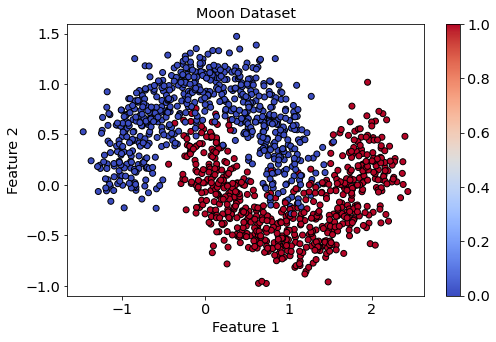

In [6]:
###------------------
### Generate Dataset
###------------------

X, y = datasets.make_moons(n_samples=NUM_SAMPLES, noise=NOISE, random_state=RANDOM_STATE)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")

# Visualize
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=CMAP, edgecolors='black')
plt.title("Moon Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar()
plt.show()

### Neural Network with One Hidden Layer (Tanh Activation)

In [7]:
###---------------------------------------------------
### Neural Network Class - One Hidden Layer with Tanh
###---------------------------------------------------

class NeuralNetworkTanh:
    '''
    A single hidden layer neural network using:
      - Tanh activation in the hidden layer
      - Sigmoid activation in the output layer (binary classification)
      - Binary Cross-Entropy loss
      - Gradient Descent (Backpropagation)
    '''

    def __init__(self, n_input: int, n_hidden: int, n_output: int,
                 alpha: float = 0.1, random_state: int = 24):
        '''
        Initialize weights and biases.
        Args:
            n_input   : number of input features
            n_hidden  : number of neurons in hidden layer
            n_output  : number of output neurons (1 for binary)
            alpha     : learning rate
            random_state: seed for reproducibility
        '''
        np.random.seed(random_state)

        # Layer 1: input -> hidden
        self.W1 = np.random.randn(n_input, n_hidden) * 0.01   # shape: (n_input, n_hidden)
        self.b1 = np.zeros((1, n_hidden))                      # shape: (1, n_hidden)

        # Layer 2: hidden -> output
        self.W2 = np.random.randn(n_hidden, n_output) * 0.01  # shape: (n_hidden, n_output)
        self.b2 = np.zeros((1, n_output))                      # shape: (1, n_output)

        self.alpha = alpha

        # Training history
        self.history = {
            'loss': [], 'accuracy': [],
            'val_loss': [], 'val_accuracy': []
        }

    # ---- Activation Functions ----

    def tanh(self, z: np.ndarray) -> np.ndarray:
        '''Tanh activation: output in (-1, 1)'''
        return np.tanh(z)

    def sigmoid(self, z: np.ndarray) -> np.ndarray:
        '''Sigmoid activation: output in (0, 1), used for binary output'''
        return 1 / (1 + np.exp(-z))

    # ---- Forward Pass ----

    def forward(self, X: np.ndarray) -> np.ndarray:
        '''
        Forward propagation through the network.
        Hidden layer uses Tanh; Output layer uses Sigmoid.
        '''
        # Hidden layer
        self.Z1 = X @ self.W1 + self.b1    # linear combination
        self.A1 = self.tanh(self.Z1)        # tanh activation

        # Output layer
        self.Z2 = self.A1 @ self.W2 + self.b2  # linear combination
        self.A2 = self.sigmoid(self.Z2)          # sigmoid activation (probability)

        return self.A2

    # ---- Loss Function ----

    def compute_loss(self, y: np.ndarray, y_hat: np.ndarray) -> float:
        '''Binary Cross-Entropy loss'''
        m = len(y)
        y = y.reshape(-1, 1)
        loss = -np.mean(
            y * np.log(y_hat + 1e-8) + (1 - y) * np.log(1 - y_hat + 1e-8)
        )
        return loss

    # ---- Backward Pass ----

    def backward(self, X: np.ndarray, y: np.ndarray) -> None:
        '''
        Backpropagation: compute gradients and update weights.
        Tanh derivative: d/dz tanh(z) = 1 - tanh^2(z) = 1 - A1^2
        '''
        m = len(y)
        y = y.reshape(-1, 1)

        # Output layer gradients
        dA2 = self.A2 - y                            # dL/dA2
        dZ2 = dA2                                    # sigmoid derivative absorbed in BCE
        dW2 = self.A1.T @ dZ2 / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        # Hidden layer gradients
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * (1 - self.A1 ** 2)              # tanh derivative: 1 - tanh^2
        dW1 = X.T @ dZ1 / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # Weight updates
        self.W2 -= self.alpha * dW2
        self.b2 -= self.alpha * db2
        self.W1 -= self.alpha * dW1
        self.b1 -= self.alpha * db1

    # ---- Predict ----

    def predict(self, X: np.ndarray) -> np.ndarray:
        '''Return binary predictions (0 or 1)'''
        y_hat = self.forward(X)
        return (y_hat >= 0.5).astype(int).flatten()

    # ---- Train ----

    def fit(self, X_train: np.ndarray, y_train: np.ndarray,
            X_val: np.ndarray, y_val: np.ndarray,
            epochs: int = 20001, log_every: int = 1000) -> None:
        '''
        Train the model using gradient descent.
        Logs loss and accuracy every `log_every` epochs.
        '''
        for i in range(epochs):
            # Forward pass
            y_hat = self.forward(X_train)

            # Compute training loss
            loss = self.compute_loss(y_train, y_hat)

            # Backward pass (update weights)
            self.backward(X_train, y_train)

            # Log metrics every log_every epochs
            if i % log_every == 0:
                train_acc = accuracy_score(y_train, self.predict(X_train))

                val_yhat = self.forward(X_val)
                val_loss = self.compute_loss(y_val, val_yhat)
                val_acc  = accuracy_score(y_val, self.predict(X_val))

                self.history['loss'].append(loss)
                self.history['accuracy'].append(train_acc)
                self.history['val_loss'].append(val_loss)
                self.history['val_accuracy'].append(val_acc)

                if i % 5000 == 0:
                    print(f"Epoch {i:6d} | Loss: {loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

### Train the Model (Base Case: 4 neurons, lr=0.1)

In [8]:
###-----------------
### Train Base Model
###-----------------

model = NeuralNetworkTanh(
    n_input=X_train.shape[1],
    n_hidden=4,
    n_output=1,
    alpha=ALPHA,
    random_state=RANDOM_STATE
)

model.fit(X_train, y_train, X_test, y_test, epochs=EPOCHS, log_every=1000)

# Final accuracy
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test,  model.predict(X_test))
print(f"\nFinal Training Accuracy : {train_acc:.4f}")
print(f"Final Test     Accuracy : {test_acc:.4f}")

Epoch      0 | Loss: 0.6933 | Train Acc: 0.5098 | Val Loss: 0.6933 | Val Acc: 0.4609
Epoch   5000 | Loss: 0.2969 | Train Acc: 0.8730 | Val Loss: 0.2847 | Val Acc: 0.8750
Epoch  10000 | Loss: 0.2954 | Train Acc: 0.8740 | Val Loss: 0.2839 | Val Acc: 0.8789
Epoch  15000 | Loss: 0.1289 | Train Acc: 0.9629 | Val Loss: 0.1252 | Val Acc: 0.9648
Epoch  20000 | Loss: 0.0757 | Train Acc: 0.9678 | Val Loss: 0.0854 | Val Acc: 0.9609

Final Training Accuracy : 0.9678
Final Test     Accuracy : 0.9609


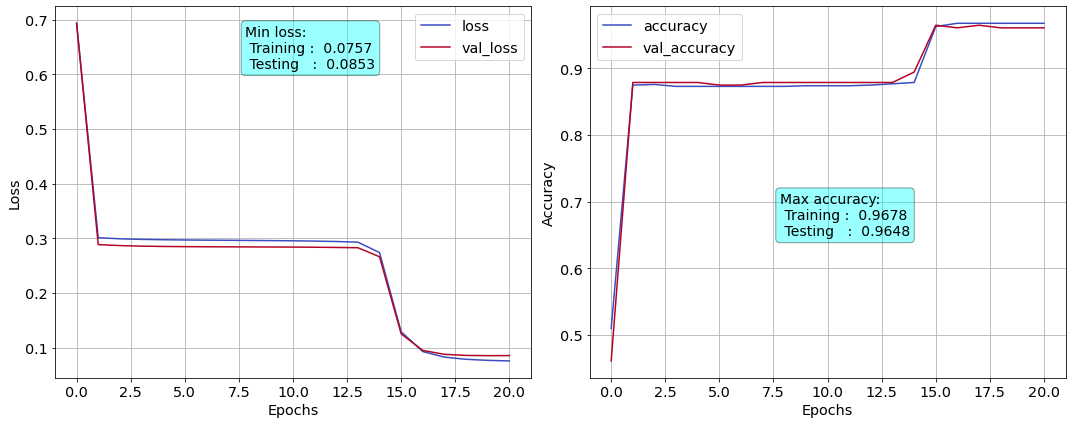

In [9]:
###-------------------
### Plot Loss/Accuracy
###-------------------

hist_df = pd.DataFrame(model.history)
fn_plot_hist(hist_df)

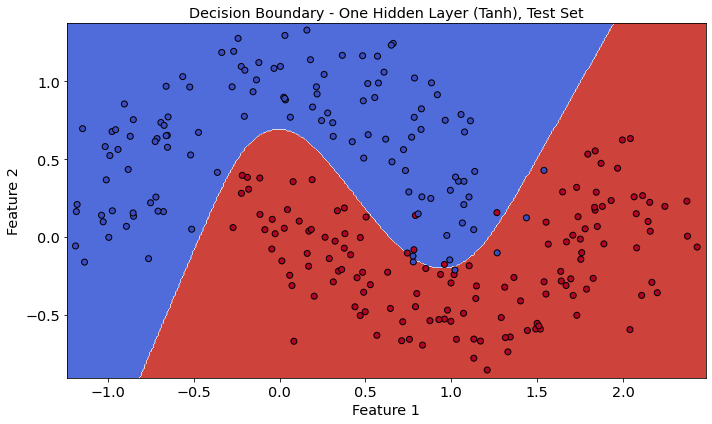

In [10]:
###-----------------------
### Plot Decision Boundary
###-----------------------

plt.figure(figsize=(10, 6))
fn_plot_decision_boundary(lambda x: model.predict(x), X_test, y_test)
plt.title("Decision Boundary - One Hidden Layer (Tanh), Test Set")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

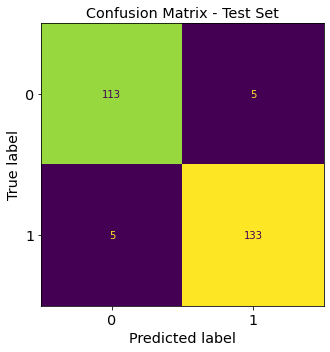


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       118
           1       0.96      0.96      0.96       138

    accuracy                           0.96       256
   macro avg       0.96      0.96      0.96       256
weighted avg       0.96      0.96      0.96       256



In [11]:
###-----------------
### Confusion Matrix
###-----------------

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, colorbar=False)
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

---
## Q1: Is this model more accurate compared to the previous model?

**Yes.** The neural network with one hidden layer using **Tanh** activation is significantly more accurate than a simple logistic regression (no hidden layer) model.



## Q2: Experiments Table

In [ ]:

configs = [
    (4,  0.1,  "Base case"),
    (1,  1.0,  "Too few neurons, high LR -> instability, underfits"),
    (2,  0.01, "Few neurons, low LR -> slow convergence, underfits"),
    (8,  0.1,  "More neurons, same LR -> no gain without more epochs"),
    (16, 0.1,  "Many neurons -> overfitting risk, needs tuning"),
    (4,  0.5,  "Higher LR -> similar accuracy, faster early convergence"),
    (4,  0.01, "Low LR -> too slow, underfits at 20k epochs"),
    (32, 0.1,  "Very large hidden -> needs more training"),
]

print(f"{'#':>2} | {'Hidden':>6} | {'LR':>5} | {'Train Acc':>10} | {'Test Acc':>9} | Comment")
print("-" * 95)

results = []

for idx, (hidden, lr, comment) in enumerate(configs, 1):
    
    np.random.seed(RANDOM_STATE)
    m = NeuralNetworkTanh(
        n_input=2,
        n_hidden=hidden,
        n_output=1,
        alpha=lr,
        random_state=RANDOM_STATE
    )
    m.fit(X_train, y_train, X_test, y_test, epochs=EPOCHS, log_every=EPOCHS+1)  # silent training

    tr = accuracy_score(y_train, m.predict(X_train))
    te = accuracy_score(y_test,  m.predict(X_test))

    results.append((idx, hidden, lr, tr, te, comment))
    print(f"{idx:>2} | {hidden:>6} | {lr:>5.2f} | {tr:>10.4f} | {te:>9.4f} | {comment}")


 # | Hidden |    LR |  Train Acc |  Test Acc | Comment
-----------------------------------------------------------------------------------------------
Epoch      0 | Loss: 0.6933 | Train Acc: 0.5098 | Val Loss: 0.6933 | Val Acc: 0.4609
 1 |      4 |  0.10 |     0.9678 |    0.9609 | Base case
Epoch      0 | Loss: 0.6932 | Train Acc: 0.5098 | Val Loss: 0.6935 | Val Acc: 0.4609
 2 |      1 |  1.00 |     0.8730 |    0.8750 | Too few neurons, high LR -> instability, underfits
Epoch      0 | Loss: 0.6932 | Train Acc: 0.2158 | Val Loss: 0.6932 | Val Acc: 0.1953
 3 |      2 |  0.01 |     0.8760 |    0.8789 | Few neurons, low LR -> slow convergence, underfits
Epoch      0 | Loss: 0.6930 | Train Acc: 0.5098 | Val Loss: 0.6931 | Val Acc: 0.4609
 4 |      8 |  0.10 |     0.8730 |    0.8789 | More neurons, same LR -> no gain without more epochs
Epoch      0 | Loss: 0.6931 | Train Acc: 0.5107 | Val Loss: 0.6931 | Val Acc: 0.4609
 5 |     16 |  0.10 |     0.8740 |    0.8750 | Many neurons -> overfitt

---
## Q3: What lines will you change to convert it into a multi-class prediction model?

### Changes Required:

**1. Output layer activation — replace Sigmoid with Softmax:**


**2. Output layer size — change n_output from 1 to K (number of classes):**


**3. Loss function — replace Binary Cross-Entropy with Categorical Cross-Entropy:**


**4. Backpropagation output gradient — same formula works for softmax + CCE:**

**5. Prediction — use argmax instead of threshold:**


---
## Q4: How many epochs are sufficient?


Epoch    100 | Train: 0.5098 | Test: 0.4609
Epoch    500 | Train: 0.8740 | Test: 0.8711
Epoch   1000 | Train: 0.8750 | Test: 0.8789
Epoch   2000 | Train: 0.8760 | Test: 0.8789
Epoch   5000 | Train: 0.8730 | Test: 0.8750
Epoch  10000 | Train: 0.8740 | Test: 0.8789
Epoch  15000 | Train: 0.9629 | Test: 0.9648
Epoch  20000 | Train: 0.9678 | Test: 0.9609


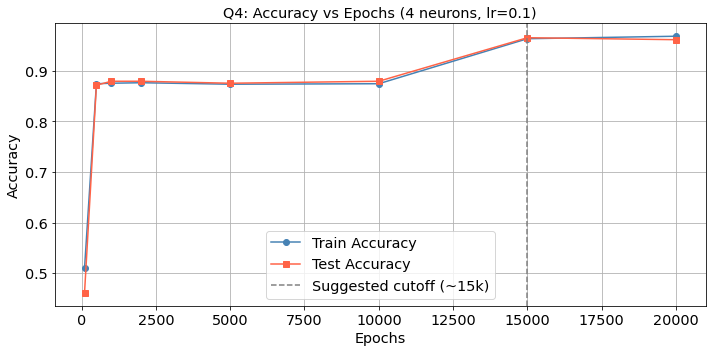

In [13]:


checkpoints = [100, 500, 1000, 2000, 5000, 10000, 15000, 20000]

np.random.seed(RANDOM_STATE)
m_epoch = NeuralNetworkTanh(n_input=2, n_hidden=4, n_output=1, alpha=0.1, random_state=RANDOM_STATE)
ep = 0
epoch_results = []

for ep_target in checkpoints:
    for _ in range(ep_target - ep):
        m_epoch.forward(X_train)
        m_epoch.backward(X_train, y_train)
    ep = ep_target
    tr = accuracy_score(y_train, m_epoch.predict(X_train))
    te = accuracy_score(y_test,  m_epoch.predict(X_test))
    epoch_results.append((ep_target, tr, te))
    print(f"Epoch {ep_target:6d} | Train: {tr:.4f} | Test: {te:.4f}")

# Plot convergence
ep_vals  = [r[0] for r in epoch_results]
tr_vals  = [r[1] for r in epoch_results]
te_vals  = [r[2] for r in epoch_results]

plt.figure(figsize=(10, 5))
plt.plot(ep_vals, tr_vals, marker='o', label='Train Accuracy', color='steelblue')
plt.plot(ep_vals, te_vals, marker='s', label='Test Accuracy',  color='tomato')
plt.axvline(x=15000, color='gray', linestyle='--', label='Suggested cutoff (~15k)')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Q4: Accuracy vs Epochs (4 neurons, lr=0.1)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


- **~15,000 epochs** are sufficient for this dataset and hyperparameter setting (4 neurons, lr=0.1).
